In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Raw chec-seq signal footprint files (see analysis code for calculations)
footprint_dir = "../Experimental_data_analysis/fimo_footprints/"
erg_fp_csv = f"{footprint_dir}hocomoco_default_pthreshold/representative_hoco_motif/raw_signals/ERG_raw_windows.csv"
atf1_fp_csv = f"{footprint_dir}hocomoco_default_pthreshold/representative_hoco_motif/raw_signals/ATF1_raw_windows.csv"
cst6_fp_csv = f"{footprint_dir}Native_Yeast_bzips/BATF3_hoco_motif/raw_signals/Cst6_raw_windows.csv"

# Motif PFMs used for the logo panels (downloadable online from HOCOMOCO v12)
gabpa_pfm = "../pfm/GABPA.H12CORE.0.PSM.A.pfm"
batf3_pfm = "../pfm/BATF3.H12CORE.2.SM.B.pfm"

## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logomaker as lm

from typing import Optional, Sequence
from matplotlib.gridspec import GridSpec

## Helper Functions

In [4]:
# Get the position columns available in a dataframe
def _pos_cols_in(df: pd.DataFrame, rng: Sequence[int]) -> list[str]:
    cols = [f"pos_{i}" for i in rng]
    return [c for c in cols if c in df.columns]


# Sort rows by signal around the motif center and keep the requested plotting window
def _sorted_and_window(df: pd.DataFrame, width: int) -> tuple[pd.DataFrame, list[str]]:
    if width < 1:
        raise ValueError("width must be >= 1")

    sort_range = range(-25, 26)
    heat_range = range(-width, width + 1)

    sort_cols = _pos_cols_in(df, sort_range)
    if len(sort_cols) == 0:
        raise ValueError("No sorting columns found (expected 'pos_-25'..'pos_25').")

    sort_sum = df[sort_cols].sum(axis=1)
    df_sorted = df.assign(_sum=sort_sum).sort_values("_sum", ascending=False).drop(columns="_sum")

    heat_cols = _pos_cols_in(df_sorted, heat_range)
    if len(heat_cols) == 0:
        raise ValueError(f"No heatmap columns found for width={width}.")

    return df_sorted, heat_cols

## Data Loading

In [5]:
# Load the raw signal windows used in the final figure
erg_fp_df = pd.read_csv(erg_fp_csv, index_col=0)
atf1_fp_df = pd.read_csv(atf1_fp_csv, index_col=0)
Cst6_dp_df = pd.read_csv(cst6_fp_csv, index_col=0)

## Plotting

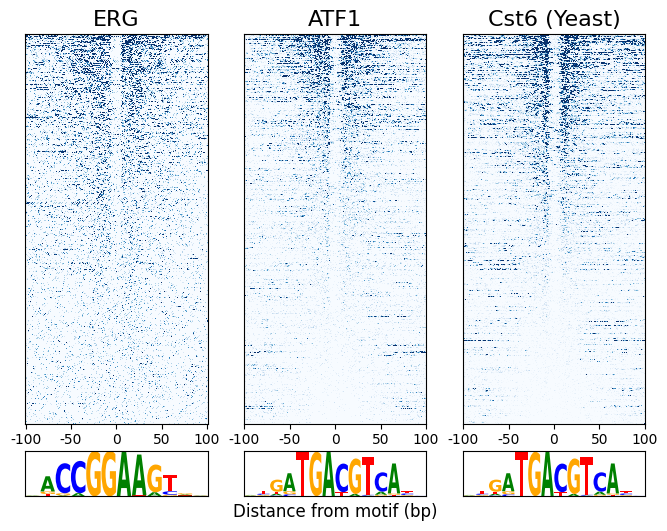

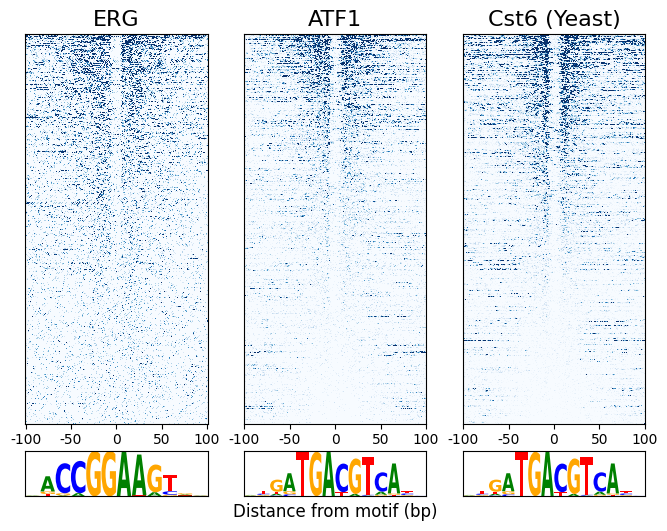

In [6]:
# Plot three positional heatmaps with optional sequence logos
def plot_three_pos_heatmaps(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    df3: pd.DataFrame,
    *,
    pfm_paths: tuple[Optional[str], Optional[str], Optional[str]] = (None, None, None),
    vmax: Optional[float] = None,
    width: int = 100,
    figsize: tuple[float, float] = (18, 7),
    rows: Optional[int] = None,
    interpolation: str = "nearest",
    show_colorbar: bool = True,
    titles: tuple[str, str, str] = ("DataFrame 1", "DataFrame 2", "DataFrame 3"),
    dropna: bool = False,
    height_ratios: tuple[float, float] = (2.5, 0.5),
    hspace: float = 0.25,
):
    df1_sorted, cols1 = _sorted_and_window(df1, width)
    df2_sorted, cols2 = _sorted_and_window(df2, width)
    df3_sorted, cols3 = _sorted_and_window(df3, width)

    if dropna:
        df1_sorted = df1_sorted.dropna(subset=cols1)
        df2_sorted = df2_sorted.dropna(subset=cols2)
        df3_sorted = df3_sorted.dropna(subset=cols3)

    n1, n2, n3 = len(df1_sorted), len(df2_sorted), len(df3_sorted)
    n = min(n1, n2, n3) if rows is None else min(rows, n1, n2, n3)

    if n <= 0:
        raise ValueError("No rows available to plot.")

    data1 = df1_sorted.iloc[:n][cols1].to_numpy()
    data2 = df2_sorted.iloc[:n][cols2].to_numpy()
    data3 = df3_sorted.iloc[:n][cols3].to_numpy()

    if vmax is None:
        vmax = np.nanmax([data1, data2, data3])
    vmin = np.nanmin([data1, data2, data3])

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        2, 3,
        height_ratios=height_ratios,
        hspace=hspace,
        figure=fig
    )

    heat_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    logo_axes = [fig.add_subplot(gs[1, i]) for i in range(3)]

    ims = []
    for ax, data, cols, title in zip(
        heat_axes,
        [data1, data2, data3],
        [cols1, cols2, cols3],
        titles
    ):
        im = ax.imshow(
            data,
            aspect="auto",
            interpolation=interpolation,
            vmin=vmin,
            vmax=vmax,
            cmap="Blues",
        )
        ims.append(im)

        ncols = len(cols)
        tick_positions = np.linspace(0, ncols - 1, num=min(ncols, 5), dtype=int)
        tick_labels = [int(cols[i].split("_", 1)[1]) for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)

        ax.set_title(title, fontsize=16)
        ax.tick_params(axis="y", left=False, labelleft=False)

    heat_axes[1].set_xlabel("Distance from motif (bp)", labelpad=40, fontsize=12)

    if show_colorbar:
        cbar = fig.colorbar(ims[-1], ax=heat_axes, fraction=0.03, pad=0.04)
        cbar.set_label("ChEC-seq cleavage signal", rotation=270, labelpad=12, fontsize=11)
        cbar.ax.tick_params(labelsize=9)

    for ax, pfm_path in zip(logo_axes, pfm_paths):
        if pfm_path is None:
            ax.set_visible(False)
            continue

        lines = []
        with open(pfm_path, "r") as fh:
            for ln in fh:
                ln = ln.strip()
                if ln:
                    lines.append(ln)

        if lines and lines[0].startswith(">"):
            lines = lines[1:]

        vals = [list(map(float, ln.split())) for ln in lines]
        arr = np.asarray(vals, dtype=float)

        counts = pd.DataFrame(arr, columns=["A", "C", "G", "T"])
        probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
        ic = lm.transform_matrix(probs, from_type="probability", to_type="information")

        lm.Logo(ic, ax=ax)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    return fig


plot_three_pos_heatmaps(
    erg_fp_df,
    atf1_fp_df,
    Cst6_dp_df,
    vmax=25,
    width=100,
    figsize=(8, 6),
    rows=None,
    pfm_paths=(gabpa_pfm, batf3_pfm, batf3_pfm),
    titles=("ERG", "ATF1", "Cst6 (Yeast)"),
    dropna=True,
    show_colorbar=False,
    height_ratios=(3, 0.35),
    hspace=0.125
)